In [2]:
import numpy as np
import matplotlib.pyplot as plt

from alntk.alignment import Alignment, find_sequence

# Find sectors to make the library

*Written by Shoichi Yip. Last updated: 13 August 2026.*

In [22]:
red_sector = np.loadtxt("../data/iter_aln_v2_redsector.txt").astype(int)
red_sector_ordered = red_sector.copy()
red_sector_ordered.sort()

In [4]:
aln = Alignment()
aln.import_from_fasta("../data/iter_aln_v2.faa")

In [6]:
aln_seqs = aln.get_seqs()

In [14]:
aln_seqs.shape

(89439, 265)

In [13]:
np.unique(["".join(row) for row in aln_seqs[:, red_sector]])

array(['A--HATG-DTTGAGGIY', 'A--NTGLQ-QVDVRGVF', 'AACMADESDQWGRAGIF', ...,
       'YYWMTGLKHTWGDADVN', 'YYWMTGLKHYWGEDDVN', 'YYYMTGLDHAWGTDDVN'],
      shape=(44751,), dtype='<U17')

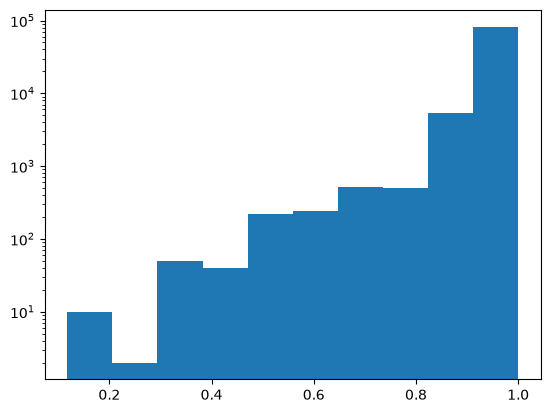

In [21]:
plt.hist(np.sum(aln_seqs[:, red_sector] != "-", axis=1) / 17)
plt.yscale("log")

In [25]:
np.unique(["".join(row) for row in aln_seqs[:, red_sector[:6]]])

array(['------', '-----A', '-----C', ..., 'YYVYKG', 'YYVYKR', 'YYVYKY'],
      shape=(12619,), dtype='<U6')

In [28]:
import numpy as np
from itertools import combinations

import numpy as np

def greedy_cluster_alignment(
    alignment,
    radius=2,
    gap="-",
    max_gaps=None
):
    alignment = np.asarray(alignment)
    n, L = alignment.shape

    gap_mask = alignment == gap
    gap_count = gap_mask.sum(axis=1)

    mask_codes = gap_mask.astype(np.uint32) @ (
        1 << np.arange(L, dtype=np.uint32)
    )

    labels = np.full(n, -1, dtype=np.int64)
    representatives = []
    representative_masks = []
    next_cluster = 0

    for mask_code in np.unique(mask_codes):
        idx = np.flatnonzero(mask_codes == mask_code)
        nongap = np.flatnonzero(~gap_mask[idx[0]])

        if max_gaps is not None and gap_count[idx[0]] > max_gaps:
            labels[idx] = next_cluster
            representatives.append(idx[0])
            representative_masks.append(mask_code)
            next_cluster += 1
            continue

        blocks = [
            block for block in np.array_split(nongap, radius + 1)
            if len(block)
        ]

        local_representatives = []
        local_labels = []
        buckets = [dict() for _ in blocks]

        for local_i in range(len(idx)):
            sequence = alignment[idx[local_i]]
            candidates = set()

            for block_i, block in enumerate(blocks):
                key = tuple(sequence[block])
                candidates.update(buckets[block_i].get(key, ()))

            assigned = False

            for rep_i in candidates:
                representative = alignment[
                    idx[local_representatives[rep_i]], nongap
                ]

                distance = np.count_nonzero(
                    sequence[nongap] != representative
                )

                if distance <= radius:
                    labels[idx[local_i]] = local_labels[rep_i]
                    assigned = True
                    break

            if not assigned:
                cluster_id = next_cluster
                next_cluster += 1

                rep_i = len(local_representatives)
                local_representatives.append(local_i)
                local_labels.append(cluster_id)
                labels[idx[local_i]] = cluster_id

                for block_i, block in enumerate(blocks):
                    key = tuple(sequence[block])
                    buckets[block_i].setdefault(key, []).append(rep_i)

        representatives.extend(
            idx[local_representatives]
        )
        representative_masks.extend(
            [mask_code] * len(local_representatives)
        )

    return labels, np.asarray(representatives), mask_codes, gap_count

In [29]:
labels, representatives, gap_masks, gap_counts = (
    greedy_cluster_alignment(
        aln_seqs[:, red_sector],
        radius=2,
        gap="-",
        max_gaps=2
    )
)

(array([8.2504e+04, 4.3640e+03, 1.4920e+03, 3.2800e+02, 4.2600e+02,
        1.8300e+02, 8.0000e+01, 4.4000e+01, 8.0000e+00, 1.0000e+01]),
 array([ 0. ,  1.5,  3. ,  4.5,  6. ,  7.5,  9. , 10.5, 12. , 13.5, 15. ]),
 <BarContainer object of 10 artists>)

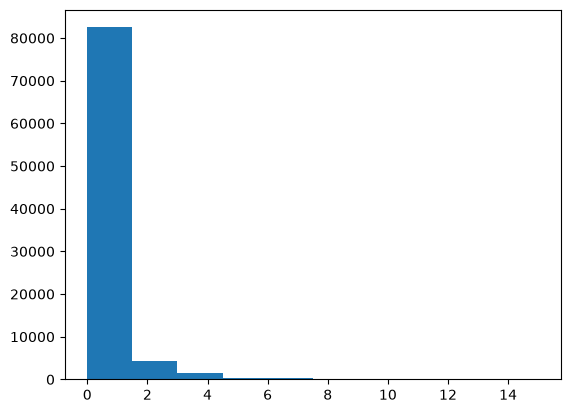

In [37]:
plt.hist(gap_counts)